# **Week 2: Natrual Language Processing and Word Embeddings**

Natural language processing with deep learning is a powerful combination. Using word vector representations and embedding layers, train recurrent neural networks with outstanding performance across a wide variety of applications, including sentiment analysis, named entity recognition and neural machine translation.

**Learning Objectives:**

- Explain how word embeddings capture relationships between words
- Load pre-trained word vectors
- Measure similarity between word vectors using cosine similarity
- Use word embeddings to solve word analogy problems such as Man is to Woman as King is to ______.
- Reduce bias in word embeddings
- Create an embedding layer in Keras with pre-trained word vectors
- Describe how negative sampling learns word vectors more efficiently than other methods
- Explain the advantages and disadvantages of the GloVe algorithm
- Build a sentiment classifier using word embeddings
- Build and train a more sophisticated classifier using an LSTM

---

## **Table of Contents**

---

## **Word Representation**

This section introduces a fundamental shift in how Deep Learning models process language, moving from simple, isolated word counts to rich, "featurized" representations. The core message is that **Word Embeddings** allow algorithms to generalize knowledge by understanding that certain words (like "apple" and "orange") are semantically similar.

### **High-level Summary**

In early NLP, computers treated words as discrete symbols, much like ID numbers in a database. This approach, known as **One-Hot Encoding**, failed because it lacked a mathematical "bridge" between related concepts. Word Embeddings solve this by placing words in a continuous, high-dimensional space where "meaning" is defined by coordinates. If "apple" and "orange" are close together in this space, the model can finally understand that what it learns about one likely applies to the other.

### **Key Takeaways**

* **The Limitations of One-Hot Vectors:**
    * Previously, words were represented as vectors with a single "1" in a specific position (e.g., $[0, 0, 1, 0]$).
    * The inner product between any two different one-hot vectors is always **0**. Consequently, the model mathematically "sees" no more similarity between "apple" and "orange" than it does between "apple" and "king." To the algorithm, every word is a total stranger to every other word.

* **Featurized Representations:**
    * By assigning a dense vector (e.g., 300 dimensions) to each word, we can represent shared characteristics like "Gender", "Royalty", "Age", or "Food status".
    * For example, "Man" might have a gender feature value of **-1**, while "Woman" has **+1**. "Apple" and "Orange" would both have high values for the "Food" feature but neutral values for "Royalty."

    <div align='center'>
        <img src='images/word_embeddings.png' width=750px>
    </div>
    <br>
    
* **Generalization & Analogies:**
    * Embeddings enable models to solve analogies via vector arithmetic (e.g., $man:woman :: king:queen$).
    * If a model learns that "orange juice" is a common phrase, the shared features in the embedding space allow it to automatically infer that "apple juice" is also a valid and likely phrase, even if it has never seen that specific combination before.

* **Visualizing High Dimensions:**
    * Since we cannot visualize 300D space, algorithms like **t-SNE** or **PCA** are used to compress these embeddings into 2D plots.
    * In these visualizations, related concepts (animals, fruits, numbers) naturally cluster together, providing visual proof that the model has "learned" semantic relationships.
    
    <div align='center'>
        <img src='images/word_embeddings_visualization.png' width=500px>
    </div>

* **Addressing Bias:**
    * Because these models learn from real-world text, they can inherit human biases related to gender, ethnicity, or socioeconomic status.
    * To resolve this problem, modern NLP involves **debiasing** (neutralizing and equalizing) these vectors to ensure the model doesn't reinforce harmful stereotypes, such as associating specific professions with only one gender.

### **One-Hot vs. Embeddings: A Comparison**

| Feature | One-Hot Encoding | Word Embeddings |
| :--- | :--- | :--- |
| **Sparsity** | Sparse (mostly zeros) | Dense (filled with floats) |
| **Vector Size** | Vocabulary size (e.g., 50,000+) | Fixed size (e.g., 300) |
| **Similarity** | **0** for all word pairs | Higher for related words |
| **Relationship** | Independent symbols | Semantic "neighbors" |
| **Generalization** | Impossible | Built-in |

---

## **Using Word Embeddings**

This section highlights how **Word Embeddings** act as a catalyst for **Transfer Learning** in NLP. The core idea is that by learning word relationships from massive, unlabeled datasets, we can significantly improve performance on specific tasks where labeled data is scarce.

### **High-level Summary**

The primary utility of word embeddings is their ability to bridge the gap between a model's lack of world knowledge and the specific requirements of an NLP task. 

Let's consider the following two sentences:

1. "Sally Robinson is an orange farmer".
2. "Robert Lin is a durian cultivator".

In a typical scenario, a model might struggle to identify "Robert Lin" as a person's name if it follows the phrase "durian cultivator"—simply because those words are rare. However, because word embeddings are "pre-trained" on nearly the entire internet, the model has already learned that a durian is a fruit (like an orange) and a cultivator is a profession (like a farmer). By swapping **one-hot vectors** for these **dense embeddings**, we "transfer" that massive internet-scale knowledge into our small, local project.

This process is fundamentally a form of transfer learning: we leverage a "Task A" (learning word relationships from billions of unlabeled sentences) to solve a "Task B" (labeling names in a few thousand sentences). While similar to **Face Encodings** in vision, the "vocabulary" approach in NLP makes word embeddings uniquely efficient for processing text with a fixed dictionary.


### **Key Takeaways**

* **Generalization through Semantic Similarity:**
    * Embeddings allow models to recognize that "durian cultivator" is conceptually similar to "orange farmer," even if the specific words "durian" or "cultivator" were never seen during the task's training phase.

* **The Three-Step Transfer Learning Process:**
    1.  **Pre-training:** Learn embeddings from a massive unlabeled corpus (1B to 100B words) or download pre-trained vectors.
    2.  **Transfer:** Apply these dense, low-dimensional vectors (e.g., 300D) to a target task with a small labeled dataset.
    3.  **Fine-tuning (Optional):** Adjust the embeddings during target task training only if the labeled dataset is sufficiently large.

* **Dimensionality Advantage:**
    * Replaces sparse, 10,000-dimensional **one-hot vectors** with dense, 300-dimensional **embedding vectors**, making the input representation much more efficient and meaningful.

* **Task Suitability:**
    * Most beneficial for tasks with limited data like **Named Entity Recognition (NER)**, text summarization, and parsing.
    * Less critical for data-rich tasks like Machine Translation or Language Modeling.

* **Embeddings vs. Face Encodings:**
    * **Similarity:** Both represent complex data as fixed-length continuous vectors (encodings).
    * **Difference:** Face recognition requires a system that can encode *any new face*, whereas word embeddings typically map a *fixed vocabulary* of words to learned vectors.

---

## **Properties of Word Embeddings**

This section explores the fascinating ability of **Word Embeddings** to perform **Analogy Reasoning** using simple vector arithmetic. By representing words in a high-dimensional space (e.g., 300D), the model captures semantic relationships as geometric distances and directions.

### **High-level Summary**

The beauty of word embeddings lies in their mathematical "common sense." By analyzing billions of words, these models realize that the leap from "man" to "woman" is spatially almost identical to the leap from "king" to "queen." It isn't just memorizing definitions; it is mapping the **structure of language** onto a coordinate system ("parallelogram" relationship).

When we ask the model an analogy, we are essentially asking it to complete a parallelogram in a 300-dimensional space. To find the missing corner, we use **Cosine Similarity**, which focuses on the direction the vectors are pointing rather than just their raw length. This allows the model to correctly identify everything from geographical capitals to grammatical patterns, providing a powerful intuition that these "dense vectors" truly capture the features of the objects they represent.

### **Key Takeaways**

* **Vector Arithmetic for Analogies:**
    * The core discovery (by [Mikolov et al.](https://scottyih.org/files/rvecs.pdf)) is that the difference between word vectors often represents a specific semantic concept.
    * For example, $e_{man} - e_{woman} \approx e_{king} - e_{queen}$. In both cases, the resulting vector represents the concept of "gender."

* **The Analogy Algorithm:**
    * To solve "Man is to Woman as King is to ??", the algorithm searches for a word $w$ that satisfies the equation:
        $$e_{man} - e_{woman} \approx e_{king} - e_w$$
    * Mathematically, this is solved by finding a word $w$ that maximizes the similarity to the vector: $e_{king} - e_{man} + e_{woman}$.

<div style='display: flex; justify-content: center'>
    <img src='images/analogies_with_word_embed.png' width=750px>
</div>

* **Cosine Similarity:**
    * The most common function used to measure how "close" two word vectors are is **Cosine Similarity**:

        $$\text{Similarity}(u, v) = \frac{u^T v}{||u||_2 ||v||_2}$$
    
    * This measures the cosine of the angle $\phi$ between vectors. If the angle is $0^\circ$, the similarity is $1$; if they are orthogonal ($90^\circ$), it is $0$.
    * Another similarity measure is negative value of square differences $-||\vec{u}  -\vec{v}||^2$. This is a less-common approach since it does not normalize for embeddings norm.

* **Broad Generalization:**
    * Embeddings can learn diverse relationships beyond gender. For example:
        * **Verb Tense:** $Go : Went :: Find : Found$
        * **Capitals:** $Ottawa : Canada :: Nairobi : Kenya$
        * **Currency:** $Yen : Japan :: Ruble : Russia$

* **Visualization Warning:**
    * While we use **t-SNE** to visualize embeddings in 2D, t-SNE is a **non-linear** mapping. We should not expect the "parallelogram" relationship of analogies to hold true in a t-SNE plot; it only reliably exists in the original high-dimensional space.

---

## **Embedding Matrix**

In this section, the focus shifts from the *why* of word embeddings to the *how*—specifically, the data structures used to store and retrieve them. The core concept introduced is the **Embedding Matrix ($E$)**, which acts as a lookup table for every word in a vocabulary.

### **High-level Summary**

Think of the **Embedding Matrix** as a giant library where every column is a book containing the "personality" of a single word. If our vocabulary has 10,000 words, we have 10,000 columns. 

When a model needs to "look up" a word like "Orange," it uses a **One-Hot Vector** as a pointer. Mathematically, when we multiply the Embedding Matrix $E$ by this pointer, the zeros in the one-hot vector cancel out every single word in the dictionary except for the one we want. The result is a clean, 300-dimensional vector that represents "Orange" in a way the neural network can actually understand.

While we represent this as matrix multiplication in theory, in practice, it’s much more efficient. Software frameworks like TensorFlow or PyTorch use specialized **"Embedding Layers"** that perform a direct index lookup (essentially just grabbing the column) to save on computation, since multiplying by a vector of zeros is technically a waste of energy!

### **Key Takeaways**

* **The Embedding Matrix ($E$):**
    * This is a massive matrix of shape $(d, V)$, where $d$ is the embedding dimension or features (e.g., **300**) and $V$ is the vocabulary size (e.g., **10,000**).
    * Each column in this matrix represents the "featurized" 300-dimensional vector for a specific word.

* **The One-Hot Vector ($O$):**
    * To find a specific word, we use a one-hot vector $O_j$, which is a $V \times 1$ vector containing a **1** at index $j$ and **0**s elsewhere.

* **Retrieval via Matrix Multiplication:**
    * Mathematically, selecting an embedding is represented as the product: $e_j = E \cdot O_j$.
    * Since the one-hot vector has only a single "1," this operation effectively "filters out" all other columns and returns only the 300-dimensional column corresponding to that specific word.

* **Notation:**
    * The resulting 300-dimensional vector is denoted as $e_j$ (or $e_{orange}$ in the example), representing the dense embedding for the $j$-th word in the vocabulary.

---

## **Learning Word Embeddings**

This section introduces how algorithms create word embeddings. It explains that while early methods were complex neural language models, researchers discovered that much simpler tasks—like predicting a word from its neighbor—can produce equally powerful word embeddings.

### **High-level Summary**

The history of word embeddings is a journey toward simplicity. Initially, researchers built full-scale neural networks to predict the next word in a sentence. To do this, the network had to "squish" words into, let's say, a 300-dimensional space. To get the answer right consistently, the network realized it was easier if it treated similar concepts (like different fruits) as being in the same "neighborhood" of that 300D space. This byproduct—the neighborhood map—is the **Embedding Matrix**.

As the field evolved, researchers realized they didn't need a complex window of four or six words to learn these relationships. They discovered that we can learn an excellent "map" of language by simply picking one random word (the context) and trying to guess another word that appears nearby (the target). This led to the creation of the **Skip-Gram** and **Word2Vec** models (see next section), which are far more computationally efficient and are the industry standards we use today.

### **Key Takeaways**

* **Learning via Language Modeling:**
    * The earliest successful embedding algorithms (like the one by [Bengio et al., (2003)](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)) were designed to solve a **Language Modeling** task: predicting the next word in a sequence (e.g., "I want a glass of orange [?]").

* **The Neural Architecture:**
    * Below is a high-level description of the language modeling approach:
        * **Input:** A fixed "historical window" of words (e.g., the previous 4 words).
        * **Embedding Layer:** Each word is converted from a one-hot vector to a 300D dense vector using a shared embedding matrix $E$.
        * **Hidden Layer:** The 4 embedding vectors are concatenated (e.g., into a 1,200D vector) and passed through a standard neural network layer.
        * **Output:** A **Softmax** layer that predicts the probability of all 10,000 words in the vocabulary being the "target" word.

    <div style='Display: flex; Justify-content: center'>
        <img src='images/neural_lm.png' width=750px>
    </div>

* **The Incentive for Similarity:**
    * To minimize loss, the model is incentivized to give "apple" and "orange" similar embeddings. This is because both words often appear before "juice," and having similar vectors allows the model to use the same internal weights to predict the correct next word.

* **Alternative Contexts for Learning:**
    * If the goal is specifically to learn embeddings (rather than a perfect language model), researchers found they could vary the **"Context"** used to predict the **"Target"**:
        * **Words on Left and Right:** Predicting the middle word from surrounding words.
        * **Last One Word:** Predicting the next word given only the immediate predecessor.
        * **Nearby One Word (Skip-Gram):** Predicting a word that appears anywhere nearby, even if it's not the immediate next word.

---

## **Skip-gram Model**

This section introduces the **Skip-gram** model, a cornerstone of the **Word2Vec** family. It explains how a seemingly "impossible" task—predicting a random neighbor word—is actually a brilliant way to force a neural network to learn high-quality word embeddings efficiently.

### **High-level Summary**

The Skip-gram model turns the challenge of "predicting the unpredictable" into a feature. Because it is very hard to guess exactly which word appears near "orange," the model is forced to learn that "orange" shares a similar environment with "apple" or "juice." To minimize its loss, the model must map these related words to similar positions in the 300-dimensional embedding space.

While the math is elegant, the sheer size of modern vocabularies makes the standard **Softmax** a major speed bottleneck. To keep the training "comfortably efficient," researchers developed the **Hierarchical Softmax**, which aims to find the right word in a tree rather than checking a list of a million words one by one. This allows Word2Vec to scale to the massive internet-sized corpora required to learn deep semantic relationships.

### **Key Takeaways**

* **The Skip-gram Concept:**
    * Unlike language models that predict the *next* word, Skip-gram picks a **Context word (c)** and tries to predict a **Target word (t)** randomly chosen from a surrounding window (e.g., $\pm 5$ or $\pm 10$ words).
    * For example, in sentence *"I want a glass of orange juice to go along with my cereal."*, if "orange" is the context, the model might try to predict "juice", "glass", or even "my".

* **The Model Architecture:**
    1.  **Input:** A one-hot vector $O_c$ for the context word.
    2.  **Embedding:** Multiply $O_c$ by the embedding matrix $E$ to get the dense vector $e_c$.
    3.  **Output:** Feed $e_c$ into a **Softmax** layer to calculate the probability of every word in the vocabulary being the target.

* **The Softmax Equation:**
    * The probability of a target word $t$ given context $c$ is:

    $$P(t|c) = \frac{e^{\theta_t^T e_c}}{\sum_{j=1}^{10,000} e^{\theta_j^T e_c}}$$

    Where $\theta_t$ is the parameter vector associated with output word $t$.

* **The Bottleneck (Computational Cost):**
    * The main disadvantage of the basic Skip-gram is the **summation in the denominator**. Summing over a vocabulary of 10,000 to 1,000,000 words for *every* training step is computationally expensive and slow.

* **Solution: Hierarchical Softmax:**
    * Instead of a flat search, Hierarchical Softmax uses a **tree-structured classifier** (often a Huffman tree). 
    * This reduces the complexity from $O(V)$ (linear) to $O(\log V)$ (logarithmic). Common words stay near the top of the tree for faster access, while rare words like "durian" are deeper.

* **Context Sampling Strategy:**
    * To prevent the model from being dominated by extremely common words (like "the," "of," "a"), researchers use heuristics to ensure less frequent but semantically rich words (like "orange" or "durian") are sampled as contexts often enough.

---

## **Negative Sampling**

This section introduces **Negative Sampling**, the definitive solution to the computational bottleneck of the standard Word2Vec Skip-gram model. By reframing a massive multi-class problem as a simple binary "True/False" test, researchers made it possible to train high-quality embeddings on massive datasets in a fraction of the time.

### **High-level Summary**

Negative Sampling is essentially a "shortcut" that yields the same high-quality results as a full neural network but at a massive discount in processing power.

The **Softmax** approach is like looking at every single word in the vocabulary and deciding if it's related to the context. By focusing only on a tiny subset of the vocabulary at each step, the Negative Sampling model learns just as effectively. It learns that "orange" and "juice" are related not by checking every other word in the English language, but by repeatedly seeing that "orange" and "juice" (positive target) are a "Yes", while "orange" and "king" (negative target) are a "No".

### **Key Takeaways**

* **From Multi-Class to Binary classifier:**
    * Instead of asking "Which of these 10,000 words is the target?" (Softmax), the model asks: "Is this pair of words a real context-target pair?" (Logistic Regression).
    * **Positive Example:** A context word (e.g., "orange") and a word actually found in its $\pm 10$ word window ("juice"). Label = $1$.
    * **Negative Examples:** The same context word ("orange") paired with $k$ random words from the dictionary ("king," "book," "the"). Label = $0$.

    <div style='display: flex; justify-content: center'>
        <img src='images/neg_sampling.png' width=400px>
    </div>

* **Computational Efficiency:**
    * In a standard 10,000-word Softmax, every training step requires updating all 10,000 sets of parameters.
    * With Negative Sampling, we only update $k+1$ binary classifiers (the 1 positive and $k$ negatives). For large datasets, $k$ is usually as small as **2 to 5** and for small datasets $k$ is usually **5 to 20**.

* **The Heuristic for Sampling ($3/4$ Power):**
    * To pick negative words, researchers found that using raw word frequency over-samples "boring" and frequent words (like "the" or "of"). Uniform sampling is also unrealistic. The solution was an emperical "middle ground formula", where words are sampled proportional to $f(w_i)^{3/4}$. This slightly increases the probability of picking less frequent words, ensuring the model stays "sharp." The model uses the Sigmoid function to predict the probability:
        
        $$P(y=1 | c, t) = \sigma(\theta_t^T e_c)$$

        $\theta_t$ is the parameter vector for the target word, and $e_c$ is the embedding for the context word.

### **Comparison of Softmax and Negative Sampling**

| Feature | Standard Softmax | Negative Sampling |
| :--- | :--- | :--- |
| **Output Type** | Probability distribution over $V$ | Binary (0 or 1) for specific pairs |
| **Updates per Step** | All $V$ parameters | Only $k+1$ parameters |
| **Best For** | Small vocabularies | Huge datasets / large vocabularies |
| **Training Speed** | $O(V)$ (Slow) | $O(k)$ (Very Fast) |

---

## **Bonus: PyTorch Implementation of Negative Sampling**

### **The Negative Sampling Architecture**

To implement the Skip-Gram Word2Vec model with **Negative Sampling**, we pivot from the standard "Predict a neighbor word" Softmax approach (which is computationally expensive for large vocabularies) toward a high-speed **Binary Classification** task. Instead of calculating a probability distribution over the entire vocabulary, the model takes two inputs—a **Context word** and a **Target word**—and predicts whether they are true neighbors ($1$) or a random pair ($0$).

### **The Training & Deployment Workflow**

The following steps outline the end-to-end process for training the model and preserving the learned embeddings for downstream tasks:

1.  **Prepare and Load the Dataset:** Tokenize the corpus and generate (context, positive target, negative samples) triplets using a sliding window.
2.  **Define the Model:** Implement a dual-embedding architecture (Context matrix $E$ and Parameter matrix $\theta$) that uses a dot product to measure word similarity.
3.  **Define the Loss Objective:** Utilize the Negative Sampling loss function, which combines the log-sigmoids of positive and negative scores.
4.  **Train the Model:** Iterate through the dataset, using backpropagation to adjust vectors until words with similar meanings cluster together.
5.  **Extract and Save Weights:** Isolate the trained (Matrix $E$) and save it to a file, discarding the temporary classification parameters.
6.  **Load for Inference:** Re-initialize a standalone embedding layer with the saved weights to perform similarity searches or analogy tasks.

### **1. Preparing and Loading the Dataset**

To train a model using **Negative Sampling**, we must structure our data into batches that contrast real word pairings with random noise. This requires a custom **Dataset** class to manage the logic of context-target pairing and a **DataLoader** to handle batching and shuffling. Note that we do not process raw text directly; instead, we pass **numerical indices** mapped from our vocabulary after the tokenization step.

Our custom `Word2VecDataset` class processes a list of sequences and, for every word, generates a training triplet:
1.  **Context:** The index of the current "center" word.
2.  **Positive Target:** The index of a word found within a local sliding window (e.g., $\pm 2$ words).
3.  **Negative Targets:** A set of $k$ random indices from the vocabulary that are *not* the positive target. These are sampled either uniformly or using the empirical **3/4 power frequency distribution** to favor more "informative" negative examples.

#### **Key technical Notes on Implementation of `Word2VecDataset` class**

* **Memory Efficiency & Regularization:**: We generate `negatives` dynamically inside the `__getitem__` method. By doing this, we avoid storing a massive, static dataset on disk. This "on-the-fly" sampling ensures that the model sees different random noise every time it encounters the same positive pair, acting as a powerful form of regularization.

* **Seamless Batching:** The PyTorch `DataLoader` automatically stacks these individual triplets into tensors. For example, with a `batch_size` of $64$ and $k=5$, the negative target tensor becomes $(64, 5)$. This perfectly aligns with the dimensions required for the **Batch Matrix Multiplication** (`torch.bmm`) used in our model's forward pass (see "Defining the Model" section.)

#### **Technical Note about `__getitem__` Method:**

This "magic method" is not fully implemented in the base `torch.utils.data.Dataset` class. It exists only as a placeholder that PyTorch requires us to define ourselves when we create a custom subclass like our `Word2VecDataset` so that the `DataLoader` knows how to fetch a specific data point (like a single Word2Vec triplet) from our data source.

```Python
def __getitem__(self, index):
    raise NotImplementedError

```

Once we defined our `__getitem__` method, we can use square bracket notation on the object to access data point:


```Python
dataset = Word2VecDataset(data, vocab_size)

# This call internally triggers dataset.__getitem__(0)
first_sample = dataset[0]

```

In [1]:
import torch
from torch.utils.data import Dataset
import random
import numpy as np


class Word2VecDataset(Dataset):
    """A PyTorch Dataset for Skip-gram word2vec with Negative Sampling.

    This class processes sequences of token indices to generate (context, target)
    positive pairs and dynamically samples negative examples to facilitate 
    training via binary logistic regression.

    Attributes:
        vocab_size (int): Total number of unique tokens in the vocabulary.
        k (int): Number of negative samples to generate for each positive pair.
        pairs (list[tuple[int, int]]): A list of all positive (context, target) word pairs.
        heuristic (bool): Whether to use the 3/4 power heuristic for negative sampling.
        unigram_probs (torch.Tensor, optional): The probability distribution used 
            for heuristic negative sampling.
    """

    def __init__(self, data, vocab_size, window_size=2, k=5, heuristic_sampling=True):
        """Initializes the Word2VecDataset with sequences and sampling parameters.

        Args:
            data (list[list[int]]): A list of tokenized sequences (e.g., sentences) 
                represented as integer indices.
            vocab_size (int): Total size of the vocabulary.
            window_size (int, optional): The maximum distance between the context 
                word and the target word. Defaults to 2.
            k (int, optional): The number of negative samples per positive pair. 
                Defaults to 5.
            heuristic_sampling (bool, optional): If True, samples negatives based on 
                the frequency distribution raised to the 0.75 power. Defaults to True.
        """
        self.vocab_size = vocab_size
        self.k = k
        self.pairs = []
        self.heuristic = heuristic_sampling
        
        # 1. Generate positive pairs: Slide a window over each sequence to find neighbors.
        # This captures the local semantic context of each token.
        for sequence in data:
            for i, context_word in enumerate(sequence):
                start = max(0, i - window_size)
                end = min(len(sequence), i + window_size + 1)
                
                for j in range(start, end):
                    if i == j: 
                        continue # A word cannot be its own Target
                    self.pairs.append((context_word, sequence[j]))
        
        # 2. Setup Negative Sampling Distribution.
        if self.heuristic:
            # Count occurrences of each token across the entire corpus.
            word_counts = np.zeros(vocab_size)
            for sequence in data:
                for word_idx in sequence:
                    if word_idx < vocab_size:
                        word_counts[word_idx] += 1
            
            # Apply the 3/4 power heuristic. 
            # This 'smooths' the distribution, making rare tokens slightly more 
            # likely to be sampled as noise than their raw frequency would suggest.
            pow_counts = np.power(word_counts + 1e-10, 0.75)
            self.unigram_probs = torch.tensor(pow_counts / np.sum(pow_counts), dtype=torch.float)
        else:
            self.unigram_probs = None

    def __len__(self):
        """Returns the total number of positive pairs in the dataset.

        Returns:
            int: Total count of (context, target) pairs.
        """
        return len(self.pairs)

    def __getitem__(self, idx):
        """Generates a training triplet: (context, target, negatives).

        This method is called by the DataLoader. Negatives are sampled 'on-the-fly'
        to provide better regularization, ensuring the model sees different noise
        in every epoch.

        Args:
            idx (int): The index of the positive pair to retrieve.

        Returns:
            tuple[torch.Tensor, torch.Tensor, torch.Tensor]: A triplet containing:
                - context (LongTensor): The center word index.
                - target (LongTensor): The positive neighbor index.
                - negatives (LongTensor): A vector of 'k' negative sample indices.
        """
        context, target = self.pairs[idx]
        
        if self.heuristic:
            # Sample k negatives using the pre-computed unigram distribution.
            negatives = torch.multinomial(self.unigram_probs, self.k, replacement=True)
            
            # Strict collision check: Ensure no negative sample is identical to 
            # the true positive target.
            for i in range(self.k):
                while negatives[i] == target:
                    negatives[i] = torch.multinomial(self.unigram_probs, 1)
        else:
            # Uniform random sampling for when heuristic is disabled.
            negatives = []
            while len(negatives) < self.k:
                neg_idx = random.randint(0, self.vocab_size - 1)
                if neg_idx != target:
                    negatives.append(neg_idx)
            negatives = torch.tensor(negatives, dtype=torch.long)
        
        return (
            torch.tensor(context, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
            negatives # Already is a Longtensor
        )

#### **Generate Mock Data for Testing `Word2VecDataset`**

To verify our implementation, we define a mock dataset with overlapping "tokens." This simulates a corpus where words appear in multiple contexts, allowing the model to learn complex semantic relationships. We assume the sentences have already been tokenized and converted into numerical indices:

```python
# Each sub-list represents a unique "sentence"
example_data = [
    [10, 20, 30, 40], # "I want a glass"
    [30, 40, 50, 60], # "a glass of orange"
    [60, 70, 80]      # "orange juice please"
]
```

This specific structure is ideal for testing the pipeline because it mimics the core mechanics of the **Word2Vec** algorithm. Specifically, the above structure would satisfy the following:

* **Validates the "Bridge" Effect:** By repeating indices across sequences (e.g., **30, 40,** and **60**), we force the model to learn second-order relationships. Even if token **10** ("I") and token **60** ("orange") never appear in the same sequence, the model connects them through their shared relationship with "glass" (**30**).

* **Tests Sequence Boundary Logic:** The varying sequence lengths (4, 4, and 3) ensure that our `Word2VecDataset` properly handles the end of one sequence without incorrectly pairing the last word of one sentence with the first word of the next.

* **Ensures Sampling Diversity:** With a defined `vocab_size` (e.g., 100), this data provides a clear contrast between **Positive Pairs** (the explicit sequences) and **Negative Samples** (the 90+ unused indices), allowing us to verify that our `3/4` power heuristic is working.

* **Simulates Semantic Clustering:** The logical "flow" of indices (10 $\to$ 80) mimics the way natural language builds meaning. This allows us to perform a quick **Cosine Similarity** check after training to see if neighboring indices (like 60 and 70) have actually clustered together in the embedding space.

In [2]:
from torch.utils.data import DataLoader


# 1. Mock Data: 3 sequences (e.g., short sentences)
# Each number is a word index from a vocab of size 100
example_data = [
    [10, 20, 30, 40], # "I want a glass"
    [30, 40, 50, 60], # "a glass of orange"
    [60, 70, 80]      # "orange juice please"
]
vocab_size = 100

# 2. Initialize Dataset
# This should generate 26 tuples of (context, positive, negatives)
dataset = Word2VecDataset(example_data, vocab_size=vocab_size, window_size=2, k=5)

# 3. Initialize DataLoader
# shuffle=True is critical for stochastic gradient descent
# This should load 13 batches of datasets
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 4. Verification
for c, t, n in dataloader:
    print(f"Contexts: {c}")
    print(f"Targets:  {t}")
    print(f"Negatives:\n{n}")
    print(10*"-")
print(len(iter(dataloader)))

Contexts: tensor([60, 10])
Targets:  tensor([70, 30])
Negatives:
tensor([[50, 30, 40, 50, 40],
        [40, 60, 40, 40, 50]])
----------
Contexts: tensor([40, 70])
Targets:  tensor([60, 80])
Negatives:
tensor([[40, 40, 50, 30, 70],
        [60, 50, 30, 40, 40]])
----------
Contexts: tensor([80, 40])
Targets:  tensor([70, 50])
Negatives:
tensor([[60, 10, 20, 60, 40],
        [60, 60, 30, 30, 60]])
----------
Contexts: tensor([30, 50])
Targets:  tensor([40, 40])
Negatives:
tensor([[50, 50, 60, 20, 30],
        [30, 10, 20, 80, 70]])
----------
Contexts: tensor([80, 70])
Targets:  tensor([60, 60])
Negatives:
tensor([[80, 30, 30, 40, 10],
        [10, 50, 10, 80, 50]])
----------
Contexts: tensor([30, 30])
Targets:  tensor([50, 10])
Negatives:
tensor([[60, 60, 60, 10, 20],
        [30, 70, 30, 30, 60]])
----------
Contexts: tensor([20, 10])
Targets:  tensor([40, 20])
Negatives:
tensor([[30, 70, 20, 10, 70],
        [30, 40, 60, 70, 70]])
----------
Contexts: tensor([30, 30])
Targets:  tens

### **2. Defining the Model**

In modern deep learning libraries like PyTorch or TensorFlow, defining a model is typically done using an **Embedding Layer** for both the context and the target, followed by a **Dot Product** to compare the embeddings (See [Why dot product?](#why-dot-product) for details).

#### **Proper Initialization of Embedding Layers**

To ensure efficient learning, we utilize an **asymmetric initialization** strategy for the $E$ (input) and $\theta$ (output) matrices. Specifically, $E$ is initialized with small, uniform random values, while $\theta$ is initialized to zero.

* **Breaking Symmetry with Random $E$:** Initializing the input matrix $E$ with **random noise** ensures that every word or token begins at a unique coordinate in the embedding space. This "breaks symmetry," preventing different tokens from receiving identical gradient updates. This allows the model to differentiate between tokens—pulling similar ones together and pushing dissimilar ones apart—from the very first iteration.

* **Establishing a Neutral Baseline with Zero $\theta$:** The matrix $\theta$ functions as a set of binary classifiers. Initializing these weights to zero is a standard practice in logistic regression, as it establishes a "neutral" baseline where $Sigmoid(0) = 0.5$. Since the model starts with $50\%$ uncertainty, the loss function immediately generates a strong gradient. This signal drives $\theta$ toward $1$ (for neighbors) or $0$ (for noise), guided by the distinct features already present in the randomized $E$ matrix.

>**Note:** In high-performance architectures, **Xavier or Kaiming initialization** is often used for both matrices to maintain stable gradient variance across layers. However, the core principle remains the same: the model requires an initial randomness to begin disentangling and mapping complex semantic relationships.

In [8]:
import torch.nn as nn


class NegativeSamplingModel(nn.Module):
    """A Word2Vec Skip-gram model implemented with Negative Sampling.

    This model implements the dual-embedding architecture where words are 
    represented by two separate vectors: one for when they act as the center 
    'context' word (Matrix E) and one for when they act as a 'target' or 
    'negative' sample (Matrix Theta).

    Attributes:
        vocab_size (int): Total number of unique tokens in the vocabulary.
        embed_size (int): Dimensionality of the embedding space.
        in_embed (nn.Embedding): The input embedding matrix (Matrix E).
        out_embed (nn.Embedding): The output embedding matrix (Matrix Theta).
    """

    def __init__(self, vocab_size, embed_size):
        """Initializes the model with vocabulary size and embedding dimensions.

        Args:
            vocab_size (int): The number of unique tokens.
            embed_size (int): The number of features in each word vector.
        """
        super().__init__() # Activate internal engine of PyTorch
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        
        # Matrix E: Used to represent the 'context' word in the sliding window.
        self.in_embed = nn.Embedding(vocab_size, embed_size)
        
        # Matrix Theta: Used to represent both positive targets and noise samples.
        self.out_embed = nn.Embedding(vocab_size, embed_size)
        
        # Initialization
        initrange = 0.5 / embed_size
        self.in_embed.weight.data.uniform_(-initrange, initrange)
        self.out_embed.weight.data.uniform_(-0, 0)

    def forward(self, input_context, input_target, input_negatives):
        """Calculates similarity scores for positive and negative word pairs.

        This method performs the dot product operations required for the 
        Negative Sampling objective. It compares a single context word against 
        one true target and 'k' negative samples.

        Args:
            input_context (torch.Tensor): LongTensor of shape [batch_size] 
                containing indices of the context words.
            input_target (torch.Tensor): LongTensor of shape [batch_size] 
                containing indices of the true positive words.
            input_negatives (torch.Tensor): LongTensor of shape [batch_size, k] 
                containing indices of the k negative samples per batch item.

        Returns:
            tuple[torch.Tensor, torch.Tensor]: A tuple containing:
                - pos_score (torch.Tensor): Similarity scores for true pairs, 
                  shape [batch_size].
                - neg_score (torch.Tensor): Similarity scores for noise pairs, 
                  shape [batch_size, k].
        """
        # 1. Lookup Embeddings
        # v_c (context): (batch, embed_size)
        v_c = self.in_embed(input_context)
        
        # u_t (positive target): (batch, embed_size)
        u_t = self.out_embed(input_target)
        
        # u_neg (negative samples): (batch, k, embed_size)
        u_neg = self.out_embed(input_negatives)

        # 2. Positive Score: Element-wise multiplication followed by sum 
        # calculates the dot product (v_c · u_t) for each pair in the batch.
        pos_score = torch.sum(v_c * u_t, dim=1) 
        
        # 3. Negative Score: Batch Matrix Multiplication (bmm).
        # We need to compute (v_c · u_neg_i) for i = 1...k.
        # We unsqueeze v_c to (batch, embed_size, 1) to treat it as a column vector.
        # u_neg (batch, k, embed_size) @ v_c (batch, embed_size, 1) = (batch, k, 1)
        neg_score = torch.bmm(u_neg, v_c.unsqueeze(2)).squeeze() 

        return pos_score, neg_score

### **3. Defining the loss objective**

The objective function's goal is to "reward" the model when it correctly identifies a real word pair and "punish" it when it fails to distinguish random noise. It is based on the logic that a good embedding should make real neighbors have a **high** dot product and random words have a **low** (or negative) dot product.

If we let $c$ be the context, $t$ be the positive target, and $\{n_1, \dots, n_k\}$ be the negative samples, the formula being calculated here is:

$$L = -\left[ \log \sigma(\theta_t^T e_c) + \sum_{i=1}^k \log \sigma(-\theta_{n_i}^T e_c) \right]$$

$$J = \frac{1}{m} \Sigma_{i=1}^m L$$

By minimizing this $L$, we are effectively forcing the model to rearrange its embeding layer so that relavent neighbors cluster together and random junk is pushed far away.

* **"Reward" for Correct Pairs:** In loss formula above, the "Reward" for Correct Pairs is:

    $$\text{Reward} = \log \sigma(\theta_t^T e_c)$$

    The goal is here is to maximize the probability that the "Positive" pair (e.g., *orange* and *juice*) is labeled as $1$. If the model is doing well, $\theta_t^T e_c$ is a large positive number. Therefore:

    $$\sigma(\text{large reward}) \approx 1 \to log(1)\approx 0$$

    This is the ideal "maximum" value for log-probability, which pushes the embeddings of $e_{orange}$ and $e_{juice}$ to point in the same direction in the embeding space.

* **The "Punishment" for Random Noise:** In loss formula above, the punishment for Negative Pairs is:

    $$\text{Punishment} = \log \sigma(-\theta_{n_i}^T e_c)$$

    The goal is to maximize the probability that the Negative pairs (e.g., *orange* and *king*) are labeled as $0$. If the model is doing well, $\theta_{n_i}^T e_c$ should be a large negative number and $-\theta_{n_i}^T e_c$ becomes a large positive number. Therefore:

    $$\sigma(\text{large panishment}) \approx 1 \to \log(1) \approx 0$$

    We sum the punishment over $k$ negative examples. We want to accumulate the "correctness" of all $k$ negative samples.

<br>

>**Note:** In deep learning, optimizers (like Adam) are designed to minimize a value. Since we want to maximize log-probability (bringing it closer to 0), we multiply by $-1$ to turn it into a "Loss" that we want to minimize. Also, we take the average over the entire batch so the gradient updates aren't too erratic.

In [10]:
class NegativeSamplingLoss(nn.Module):
    """Calculates the Noise Contrastive Estimation loss for Word2Vec.

    This loss function implements the negative sampling objective introduced in 
    the original Word2Vec paper. It maximizes the probability of the true 
    neighbor (positive pair) while simultaneously minimizing the probability 
    of 'k' noise samples (negative pairs).

    The mathematical formulation is:
    Loss = -[ log(sigmoid(pos_score)) + sum(log(sigmoid(-neg_scores))) ]
    """

    def __init__(self):
        """Initializes the NegativeSamplingLoss module."""
        super().__init__()

    def forward(self, pos_score, neg_score):
        """Computes the Negative Sampling loss for a batch of samples.

        Args:
            pos_score (torch.Tensor): Predicted similarity scores for true 
                context-target pairs. Shape: [batch_size].
            neg_score (torch.Tensor): Predicted similarity scores for negative 
                samples. Shape: [batch_size, k].

        Returns:
            torch.Tensor: The scalar mean loss value for the batch, 
                suitable for backpropagation.
        """
        # 1. Calculate Positive Loss
        pos_loss = torch.log(torch.sigmoid(pos_score))
        
        # 2. Calculate Negative Loss
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_score)), dim=1)
        
        # 3. Combined Average Loss:
        return -torch.mean(pos_loss + neg_loss)

### **4. Training the Model**

During every training step of a Word2Vec model—specifically the **Skip-gram with Negative Sampling** architecture—**both** the Context Embeddings (matrix $E$) and the Target/Parameter Embeddings (matrix $\theta$) are updated. 

When we perform the backward pass (`loss.backward()`), the gradients flow through the dot product calculation and back into both embedding layers:

* **Context Embeddings Update ($E$):** The model adjusts the vector $e_c$ for the **Context word** (e.g., *orange*) to bring it mathematically closer to the real target and further from the noise.
* **Target/Parameter Embeddings Update ($\theta$):** The model adjusts the vector $\theta_t$ for the **Target word** (e.g., *juice*) to make it more receptive to the context word *orange*. Simultaneously, it pushes the vectors $\theta_n$ of the **Negative words** (e.g., *king*, *book*) away from *orange*.

#### **The Mechanics of Gradient Management in PyTorch**

When training deep learning models, how we handle the "mathematical memory" of our gradients is just as critical as the model architecture itself. Understanding the interaction between the optimizer, the backward pass, and the memory buffers is key to stable convergence.

##### **Gradient Accumulation**
In PyTorch, gradients are **accumulated** by default. Mathematically, every time we call `loss.backward()`, PyTorch performs an addition operation:
$$\nabla_{W} L_{total} = \nabla_{W} L_{old} + \nabla_{W} L_{new}$$
Calling `optimizer.zero_grad()` resets this buffer to zero: $\nabla_{W} L = \mathbf{0}$.

If we don't reset the gradients between batches, the model effectively tries to optimize for the current batch while being pulled by the "ghosts" of every previous batch. This leads to massive, exploding gradient values that cause the training to fail.

##### **Why not reset automatically?**
PyTorch’s decision not to reset gradients automatically is a strategic "hardware hack." If our GPU can only fit a batch of **8**, but our model requires a batch of **64** to be stable, we can run 8 consecutive batches of 8, calling `backward()` after each one **without** zeroing the gradients. On the 8th iteration, the buffer contains the sum of all 64 samples. Calling `optimizer.step()` and `zero_grad()` only once at the end allows us to train massive models on consumer-grade hardware by "polling" the data over multiple steps.

##### **Performance Optimization: `set_to_none=True`**
In modern PyTorch, we will often see:
`optimizer.zero_grad(set_to_none=True)`

While mathematically identical to setting gradients to zero, it is computationally faster. Instead of performing an $O(N)$ write operation to fill memory with zeros, it simply deletes the gradient tensor (`None`). PyTorch then allocates a new tensor during the next `backward()` pass, reducing total memory "write" operations.


#### **The `__call__` vs. `forward()` Distinction**

In Python, defining a `__call__` method allows an instance of a class to be treated like a function:

```python
class Greeter:
    def __call__(self, name):
        return f"Hello, {name}!"

say_hi = Greeter()
print(say_hi("Student"))  # Triggers __call__ automatically
```

Every PyTorch model inherits from `nn.Module`, which implements `__call__` to act as a **manager** for our model. Its internal logic looks roughly like this:

```python
# Simplified internal PyTorch source
class Module:
    def __call__(self, *input, **kwargs):
        # 1. Pre-processing: Background "Hooks" 
        # 2. THE CORE CALL: Executes your forward() method
        result = self.forward(*input, **kwargs) 
        # 3. Post-processing: State management and cleanup
        return result
```

When we run `model(context_idx, ...)`, we are executing the `__call__` method, which in turn runs our `forward` logic. While we *could* call `model.forward()` directly, it is **bad practice**. Using the functional call `model()` ensures PyTorch performs essential background tasks:
* **Hooks:** Triggers "Forward Hooks" used for debugging or visualizing internal activations (e.g., Grad-CAM).
* **State Management:** Handles internal logic for distributed training and hardware acceleration.
* **Safety Checks:** Verifies that inputs, weights, and device placements (CPU/GPU) are properly aligned.


#### **Real-time Monitoring with `tqdm`**

To monitor the "heartbeat" of our training, we wrap our `DataLoader` with the `tqdm` library. This provides a visual progress bar with critical real-time feedback, including iterations per second, elapsed time, and Estimated Time of Completion (ETA). 

**Basic `tqdm` Example:**
```python
from tqdm import tqdm
import time

# Wrapping an iterable to create a progress bar
for i in tqdm(range(10), desc='Processing Items'):
    time.sleep(1) # Simulate heavy computation
```

By combining these tools—proper gradient management, functional model calls, and real-time monitoring—we create a training loop that is not only mathematically sound but also efficient and easy to debug.

In [24]:
import torch.optim as optim
from tqdm import tqdm


# --- Hyperparameters ---
# vocab_size: Total unique tokens (e.g., words or amino acid motifs).
# embed_size: The number of dimensions in the learned semantic space.
# k: The ratio of noise to signal; for each positive pair, we sample k negatives.
vocab_size = 10000
embed_size = 300
k = 5 

# --- Initialization ---
# Initialize the dual-embedding architecture.
model = NegativeSamplingModel(vocab_size, embed_size)

# The Log-Sigmoid objective function.
criterion = NegativeSamplingLoss()

# Adam optimizer handles the adaptive learning rate for every individual 
# parameter (coordinate) in our embedding matrices.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# History containers for visualization and debugging.
batch_loss_history = []
epoch_loss_history = []

# --- Training Execution ---
epochs = 20
for epoch in range(epochs):
    total_epoch_loss = 0
    
    # tqdm provides a visual progress bar for real-time monitoring.
    # Assume 'dataloader' is a PyTorch DataLoader yielding triplets.
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    
    # Set model to training mode. This ensures that internal state (like 
    # gradients) is tracked and that dropout (if any) is active.
    model.train() 
    
    for context_idx, target_idx, negative_indices in progress_bar:
        # 1. Zero Gradients: PyTorch accumulates gradients by default. 
        # We must clear the 'workbench' before starting a new calculation.
        optimizer.zero_grad(set_to_none=True)
        
        # 2. Forward Pass: Computes the similarity scores for the batch.
        # Calling model() triggers the .forward() method internally.
        pos_scores, neg_scores = model(context_idx, target_idx, negative_indices)
        
        # 3. Compute Loss: Apply the Negative Sampling (Noise Contrastive) objective.
        loss = criterion(pos_scores, neg_scores)
        
        # 4. Backward Pass: Calculate the gradient of the loss with respect 
        # to every weight in E and Theta using the chain rule.
        loss.backward()
        
        # 5. Optimizer Step: Update the weights based on the gradients.
        # This is where the vectors actually "move" in the embedding space.
        optimizer.step()
        
        # 6. Logging: Extract the scalar value from the loss tensor.
        current_loss = loss.item()
        batch_loss_history.append(current_loss)
        total_epoch_loss += current_loss

        # Update the progress bar with the most recent batch loss.
        progress_bar.set_postfix({'loss': f"{current_loss:.4f}"})
        
    # Calculate and store the average loss for the entire epoch.
    avg_epoch_loss = total_epoch_loss / len(dataloader)
    epoch_loss_history.append(avg_epoch_loss)
    print(f"--- Epoch {epoch+1} Complete. Avg Loss: {avg_epoch_loss:.4f} ---")

Epoch 1/20: 100%|██████████| 13/13 [00:00<00:00, 39.23it/s, loss=4.1510]


--- Epoch 1 Complete. Avg Loss: 4.1571 ---


Epoch 2/20: 100%|██████████| 13/13 [00:00<00:00, 37.61it/s, loss=4.0999]


--- Epoch 2 Complete. Avg Loss: 4.1325 ---


Epoch 3/20: 100%|██████████| 13/13 [00:00<00:00, 31.42it/s, loss=3.9983]


...

--- Epoch 18 Complete. Avg Loss: 2.6428 ---


Epoch 19/20: 100%|██████████| 13/13 [00:00<00:00, 37.80it/s, loss=2.5738]


--- Epoch 19 Complete. Avg Loss: 2.6242 ---


Epoch 20/20: 100%|██████████| 13/13 [00:00<00:00, 36.87it/s, loss=2.5903]

--- Epoch 20 Complete. Avg Loss: 2.6147 ---


Let's visualize how how the loss changes in each training epoch:

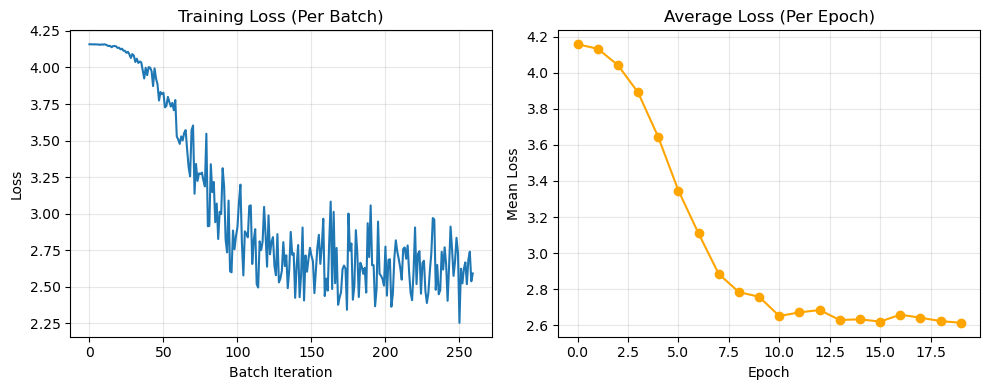

In [25]:
import matplotlib.pyplot as plt


# 1. Setup the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)
ax1, ax2 = axes.flatten()

# 2. Plot Batch-level Loss
# This shows the "noisy" loss calculated at every individual step.
# High volatility here is normal but should generally trend downward.
ax1.plot(batch_loss_history)
ax1.set_title("Training Loss (Per Batch)")
ax1.set_xlabel("Batch Iteration")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3) # Added for better readability

# 3. Plot Epoch-level Loss
# This provides a "smoothed" view of the model's overall progress.
ax2.plot(epoch_loss_history, '-o', color='orange')
ax2.set_title("Average Loss (Per Epoch)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean Loss")
ax2.grid(True, alpha=0.3)

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()
plt.show()

### **5. Extracting and Saving Weights**

Saving our trained embeddings is the critical final step of the pipeline. Once training is complete, the `out_embed` (the $\theta$ parameters) has fulfilled its role as a temporary binary classifier. The `in_embed` (the $E$ matrix) is the "gold" representation we intend to preserve for downstream applications.

#### **Embedding Selection:**
Matrix $E$ is what is traditionally referred to as "The Word Embeddings." However, some researchers prefer to use the **average** of the two matrices ($(E + \theta)/2$) to produce a final representation, which can occasionally be more robust. In most standard pipelines, Matrix $\theta$ is discarded after training because its primary function was to serve as the "classifier weights" for the negative sampling task. We will use `torch.save` to export the internal `state_dict` of the embedding layer to a `.pt` or `.pth` file for persistent storage.

#### **Why Export Only the `in_embed` Weights?**
By saving only the `in_embed` matrix, we are effectively exporting the "semantic map" discovered by the model while discarding the auxiliary parameters used during training. This approach offers two major advantages:

* **Reduced Memory Footprint:** The resulting file is significantly smaller because it excludes the `out_embed` parameters ($\theta$) and the internal states of the optimizer (like Adam’s momentum buffers).
* **Plug-and-Play Utility:** In a production environment, these weights act as a high-quality "head start" for more complex architectures, such as **Transformers**, which benefit from initialized "meanings" rather than random noise.

In [26]:
# Path to save the file
SAVE_PATH = "embeddings_v1.pt"

# Extract only the 'in_embed' weights (the E matrix)
# This is a tensor of shape [vocab_size, embed_size]
embedding_weights = model.in_embed.state_dict()

# Save to disk
torch.save(embedding_weights, SAVE_PATH)
print(f"Successfully saved embeddings to {SAVE_PATH}")

Successfully saved embeddings to embeddings_v1.pt


### **6. Loading the Embeddings for Inference**

To perform downstream tasks like similarity search or analogy reasoning, we no longer require the full `NegativeSamplingModel`. Instead, we can use a standard `nn.Embedding` layer as a container for our pre-trained weights. Once these weights are loaded, we can identify semantically related tokens by calculating the **Cosine Similarity** between their respective vectors.

#### **Turning on Evaluation Mode**

Calling `final_embeddings.eval()` is a critical step that transitions a PyTorch model from **Training Mode** to **Evaluation Mode**. Briefly, calling `eval()` method:

* Flips a global boolean flag (`self.training`) within the model. This tells specific layers—like **Dropout** and **Batch Normalization**—to stop their training-specific behaviors (like randomly dropping neurons or updating running means) and use their "learned" stable configurations instead.
* Ensures that the model's output is deterministic. During inference, we want the same input to produce the exact same output every time, which wouldn't happen if Dropout remained active.
* Is an industry-standard safeguard that ensures the model is prepared for inference even if our model only contains simple Embedding layers.

#### **Crucial Distinction: `.eval()` vs. `torch.no_grad()`**
While `.eval()` changes the behavior of the layers, it does **not** stop the mathematical calculation of gradients. To speed up inference and save memory, we must combine it with `torch.no_grad()` context manager:

```python
model.eval()           # Set behavior (Disable Dropout)
with torch.no_grad():  # Set memory (Disable Gradient math)
    # Inference code here
```

In [ ]:
def get_most_similar(word_idx, embedding_layer, top_k=5):
    """Identifies the nearest neighbors of a word in the embedding space.

    This function performs a similarity search across the entire vocabulary 
    using Cosine Similarity, which measures the angular distance between vectors.

    Args:
        word_idx (int): The vocabulary index of the query word.
        embedding_layer (nn.Embedding): The trained PyTorch embedding layer.
        top_k (int, optional): Number of similar words to return. Defaults to 5.

    Returns:
        tuple[torch.Tensor, torch.Tensor]: A tuple containing:
            - indices: The vocabulary IDs of the top_k most similar words.
            - values: The corresponding cosine similarity scores (range -1 to 1).
    """
    # 1. Retrieve the vector for the query word. 
    # Shape becomes [1, embed_size].
    target_vec = embedding_layer(torch.tensor([word_idx])) 
    
    # 2. Access the full weight matrix (Matrix E).
    # Shape is [vocab_size, embed_size].
    all_vecs = embedding_layer.weight 
    
    # 3. Calculate Cosine Similarity.
    # We compare the target_vec against all_vecs simultaneously.
    # Cosine Similarity = (A · B) / (||A|| * ||B||)
    cos = nn.CosineSimilarity(dim=1)
    similarities = cos(target_vec, all_vecs)
    
    # 4. Extract top results.
    # We ask for k+1 because the most similar word is always the word itself 
    # (similarity = 1.0). We then slice [1:] to skip the self-match.
    values, indices = torch.topk(similarities, top_k + 1)
    
    return indices[1:], values[1:]

# --- Execution Block ---

# Configuration must match the training setup
vocab_size = 10000 
embed_size = 300

# Re-initialize a standalone layer to hold the trained weights
final_embeddings = nn.Embedding(vocab_size, embed_size)

# Load the saved state: weights_only=True is a security best practice to 
# prevent the execution of malicious pickled code.
final_embeddings.load_state_dict(torch.load("embeddings_v1.pt", weights_only=True))

# 1. .eval() sets the behavior for inference (disables dropout, etc.)
final_embeddings.eval()

# 2. torch.no_grad() disables the computational graph, saving memory and CPU/GPU.
with torch.no_grad():
    # Example: Query the semantic neighbors for index 60 (e.g., 'orange')
    similar_indices, scores = get_most_similar(60, final_embeddings)
    
    print(f"Indices of words similar to 'orange': {similar_indices.tolist()}")
    print(f"Scores of words similar to 'orange': {scores.tolist()}")

Indices of words similar to 'orange': [80, 70, 40, 50, 10]
Scores of words similar to 'orange': [0.9757442474365234, 0.963614821434021, 0.9016527533531189, 0.8600608110427856, 0.8402314186096191]


#### **Note on Model Performance**
In the example above, we notice that the semantic neighbors for our query word (e.g., *orange*) are not yet perfectly accurate. This is expected behavior. Achieving "human-like" semantic relationships usually requires training on massive corpora (millions of sentences) and more complex architectures.

The primary goal of this exercise was not to produce a production-ready language model, but rather to demonstrate the **standard end-to-end training workflow**: from data preparation and gradient management to weights extraction and similarity search.

Here is why a simple model might struggle initially:

* **Data Sparsity:** If the word "orange" only appears five times in our dataset, the model hasn't seen enough varied contexts to decide if it’s a fruit, a color, or a brand.
* **The "Alignment" Problem:** Early in training, the $E$ (Context) and $\theta$ (Target) matrices might not be perfectly aligned. Often, the Context matrix ($E$) contains more "meaning," while the Target matrix ($\theta$) is more biased toward word frequency.
* **Embed Size vs. Vocab Size:** If our `embed_size` is too small for a huge vocabulary, the model suffers from "bottlenecking"—it doesn't have enough "room" to move words away from each other.

---

### **Bonus: Why Use Dot Product Instead of Cosine Similarity in Training?**

While Cosine Similarity is the gold standard for finding analogies ($Man:Woman :: King:Queen$) after a model is trained, we almost exclusively use the **Dot Product** ($\theta^T e$) during the actual Negative Sampling training phase. 

The decision to avoid Cosine Similarity during training comes down to two factors: **computational efficiency** and how the model encodes **word importance**.

##### **1. The Computational Bottleneck**
The most practical reason is speed. A **Dot Product** is a simple operation consisting only of multiplication and addition. In contrast, **Cosine Similarity** requires calculating the dot product *plus* the $L_2$ norm (the square root of the sum of squares) for every vector in the operation. When training on a corpus of billions of words, adding square root and division operations to every single weight update significantly slows down convergence.

##### **2. The Significance of Vector Magnitude (Norm)**
In a Dot Product, the result is determined by both the **angle** and the **magnitude (length)** of the vectors:

$$u \cdot v = \|u\| \|v\| \cos(\phi)$$

By using Cosine Similarity, we would be normalizing all vectors to a length of $1$, effectively discarding their magnitude. In Word2Vec, however, the length of a vector carries vital information:

* **Frequent Tokens:** Words that appear often (like "the" or "of") receive more frequent gradient updates, leading to larger norms.
* **Rare Tokens:** Words seen only a few times remain closer to the origin, resulting in **smaller norms**.

By utilizing the Dot Product, the model uses vector length to represent "confidence" or "frequency," which allows the objective function to converge more naturally.

---

## GloVe Word Vectors

This section provides a breakdown of the **GloVe (Global Vectors for Word Representation)** algorithm. While Word2Vec relies on local window sampling, GloVe focuses on the "global" statistics of how often words co-occur across an entire text corpus.

### High-level Summary

The fundamental shift in GloVe is moving from **sampling** (looking at individual pairs one by one) to **counting**. It builds a large co-occurrence matrix, $X$, where $X_{ij}$ represents how many times word $j$ (target) appears in the context of word $i$. The goal is to create word vectors whose dot product accurately predicts the log of these co-occurrence counts.

The beauty of GloVe lies in its simplicity. It essentially turns a complex linguistic problem into a **weighted least squares regression** problem. By looking at the "Global" state of the language (the entire $X$ matrix) rather than just "Local" snapshots (Skip-grams), it captures the macro-relationships of a language more efficiently. While we might not be able to look at a particular feature in a word embedding, the overall vector space becomes a powerful tool for sentiment analysis and analogy reasoning because the *relative* distances between words are preserved.

### Key Takeaways

* **The Objective Function:** The model minimizes the squared difference between the dot product of two vectors ($\theta_i^T e_j$) and the logarithm of their co-occurrence count ($\log X_{ij}$):

    $$\text{Minimize} \sum_{i,j} f(X_{ij}) (\theta_i^T e_j + b_i + b_j - \log X_{ij})^2$$

    To undestand why we take $log$ of $X_{ij}$ and use a weighting function in the loss function, see the following [bonus](#bonus-the-mathematical-intuition-behind-glove-loss-function) section.

* **The Weighting Function $f(X_{ij})$:**

    * It handles the problem of $\log(0)$ by setting the weight to zero if the words never co-occur.
    * It acts as a heuristic to balance the "continuum" of word frequencies. It ensures common words (like "the," "is") don't dominate the loss, while rare words (like "durian") still receive enough weight to be meaningful.

* **Symmetry and Averaging:** In GloVe, the context and target vectors ($\theta$ and $e$) are mathematically symmetric. Because they play identical roles in the equation, a common practice is to train both and then use their **average** ($\frac{e + \theta}{2}$) as the final word embedding.

* **The Problem of Interpretability:**

    * Even though we want embeddings to represent clear features like "Gender" or "Royalty," the algorithm cannot guarantee that any single dimension (e.g., the first row) corresponds to a human-interpretable trait. 
    * Due to potential linear transformations during optimization, a single dimension might be a "mixture" of many different semantic concepts.

* **Analogy Preservation:** Despite the lack of individual row interpretability, the global geometric relationships—like the **parallelogram map** used for analogies ($Man:Woman :: King:Queen$)—remain intact and highly effective.

---

## Bonus: The Mathematical Intuition Behind GloVe Loss Function

The GloVe objective function isn't just a random formula; it is a carefully engineered "weighted least squares" regression. Two specific components—the **Logarithm** and the **Weighting Function**—work together to solve the massive scaling issues inherent in natural language.

### 1. Why the Logarithm?

The use of the logarithm in the GloVe objective function is a "mathematical trick" that solves the problem of high-frequency "stop words" (like *the* or *and*) drowning out meaningful terms.

#### Compressing the Dynamic Range
In any large corpus, word frequencies follow **Zipf’s Law**, meaning the most frequent word occurs roughly twice as often as the second most frequent, and so on.

* **The Problem:** The co-occurrence count $X_{ij}$ for "of the" might be **1,000,000**, while "durian fruit" might be **1**. If we tried to predict raw counts, the squared error from a single mistake on "of the" would be $(10^6)^2$ times larger than a mistake on a rare word. 
* **The Solution:** Taking the **logarithm** squashes this astronomical range. Instead of comparing $1$ to $1,000,000$, the model compares $\log(1) = 0$ to $\log(1,000,000) \approx 13.8$. This puts rare and frequent words on a level playing field.

#### Mapping Multiplicative Ratios to Linear Distances
Linguistics is naturally **multiplicative**. We often understand word relationships through ratios of probabilities. For example:

$$\frac{P(\text{solid} \mid \text{ice})}{P(\text{solid} \mid \text{steam})} \approx \text{Large Ratio}$$

By using $\log(X_{ij})$, we transform these multiplicative ratios into simple **vector subtractions**:

$$\log\left(\frac{A}{B}\right) = \log(A) - \log(B)$$

This allows the dot product $\theta_j^T e_i$ to represent relative strength linearly, which is precisely why "parallelogram analogies" (like $King - Man + Woman = Queen$) work so well in the resulting vector space.

#### Theoretical Alignment with Skip-Gram
In the Skip-gram (Word2Vec) model, the probability of a target word $j$ given context $i$ is modeled via Softmax:

$$P(j \mid i) = \frac{\exp(\theta_j^T e_i)}{\sum \exp(\dots)}$$

If we take the log of a simplified version of this probability, we find that $\log P(j \mid i) \approx \theta_j^T e_i$. The creators of GloVe realized that if the dot product represents log-probability, and probability is proportional to the count ($X_{ij}$), then the dot product must be approximately equal to the log-count to keep the model's internal similarity scores and external counts on the same scale.



### 2. Why the Weighting Function $f(X_{ij})$?

The weighting function is the model's final "safety valve." While the logarithm squashes the numerical range, the weighting function determines how much the model should actually care about a specific co-occurrence pair during a gradient update.

#### The Shape of $f(X_{ij})$
The function $f(X_{ij})$ is designed to satisfy three common-sense rules:
1.  **$f(0) = 0$:** If words never occur together, they contribute nothing (this also avoids the $\log(0)$ error).
2.  **Monotonicity:** $f(x)$ increases with $x$ so that frequent pairings carry more weight than rare ones.
3.  **The "Ceiling" Effect:** The weight plateaus for extremely frequent words so they don't dominate the entire model.

The standard heuristic is:

$$f(x) = \begin{cases} (x/x_{max})^\alpha & \text{if } x < x_{max} \\ 1 & \text{if } x \ge x_{max} \end{cases}$$

* **Boosting the rare words ($\alpha$ Power):** By setting $\alpha$ (typically $0.75$), the function gives a "boost" to mid-frequency words. The curve is steeper at the beginning, ensuring that words like "durian" get enough weight to move their vectors significantly.
* **The $x_{max}$ cap for stop words:** By setting $x_{max}$ (usually $100$), we declare that once two words have appeared together $100$ times, the relationship is "fully confirmed." Whether they appear $100$ or $1,000,000$ times, the weight stays at $1$. This prevents "stop-words" from drowning out the rest of the vocabulary.

---

## Bonus: PyTorch Impelmentation of GloVe Algorithm

Implementing GloVe in PyTorch is a bit different from Word2Vec. Instead of iterating through a sliding window during training, we treat it as a **Weighted Least Squares Regression** problem. We assume we have already pre-calculated a "Co-occurrence Matrix" $X$.

Here is a clean, modular implementation.

### 1. The GloVe Model Architecture
The model consists of two embedding layers ($E$ and $\theta$) and two bias vectors. As wedescribed above, these are symmetric.

```python
import torch
import torch.nn as nn
import torch.optim as optim

class GloVeModel(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super(GloVeModel, self).__init__()
        # Symmetric embeddings
        self.in_embed = nn.Embedding(vocab_size, embed_size)
        self.out_embed = nn.Embedding(vocab_size, embed_size)
        
        # Biases for each word (crucial for the GloVe objective)
        self.in_bias = nn.Embedding(vocab_size, 1)
        self.out_bias = nn.Embedding(vocab_size, 1)
        
        # Initialize weights
        nn.init.uniform_(self.in_embed.weight, -0.1, 0.1)
        nn.init.uniform_(self.out_embed.weight, -0.1, 0.1)
        nn.init.zeros_(self.in_bias.weight)
        nn.init.zeros_(self.out_bias.weight)

    def forward(self, i_indices, j_indices):
        # i = context word, j = target word
        w_i = self.in_embed(i_indices)   # [batch, embed_size]
        w_j = self.out_embed(j_indices)  # [batch, embed_size]
        
        b_i = self.in_bias(i_indices).squeeze() # [batch]
        b_j = self.out_bias(j_indices).squeeze() # [batch]
        
        # Dot product: \theta_j^T * e_i
        dot_product = torch.sum(w_i * w_j, dim=1)
        
        # Prediction: \theta_j^T * e_i + b_i + b_j
        return dot_product + b_i + b_j
```

### 2. The Weighted Loss Function
We need to implement the weighting function $f(X_{ij})$ and the squared error against $\log(X_{ij})$.

```python
class GloVeLoss(nn.Module):
    def __init__(self, x_max=100, alpha=0.75):
        super(GloVeLoss, self).__init__()
        self.x_max = x_max
        self.alpha = alpha

    def forward(self, predictions, counts):
        # 1. Calculate f(X_ij) weights
        # weight = (x/x_max)^alpha if x < x_max else 1
        weights = torch.pow(counts / self.x_max, self.alpha)
        weights = torch.where(counts < self.x_max, weights, torch.ones_like(weights))
        
        # 2. Calculate squared error: (pred - log(counts))^2
        # Note: counts should be >= 1 here (handled by Dataset)
        loss = weights * torch.pow(predictions - torch.log(counts), 2)
        
        return torch.mean(loss)
```

### 3. The Dataset Logic
Unlike the Skip-gram dataset, this one returns the **pre-calculated count** for a specific pair.

```python
from torch.utils.data import Dataset, DataLoader

class GloVeDataset(Dataset):
    def __init__(self, co-occurrence_matrix):
        """
        co-occurrence_matrix: A dictionary or sparse matrix 
        where keys are (i, j) and values are counts X_ij.
        """
        # We only store pairs where count > 0
        self.indices = list(co-occurrence_matrix.keys())
        self.counts = list(co-occurrence_matrix.values())

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i, j = self.indices[idx]
        count = self.counts[idx]
        return torch.tensor(i), torch.tensor(j), torch.tensor(count, dtype=torch.float)
```

### 4. Training and Weight Averaging
Finally, we train and—as per the "symmetric roles" discussed—average the weights.

```python
# Initialization
model = GloVeModel(vocab_size=10000, embed_size=300)
criterion = GloVeLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(20):
    for i, j, counts in dataloader:
        optimizer.zero_grad()
        preds = model(i, j)
        loss = criterion(preds, counts)
        loss.backward()
        optimizer.step()

# --- Post-Training: Symmetric Averaging ---
# As Pennington et al. suggested, averaging in_embed and out_embed 
# often results in more robust vectors.
final_embeddings = (model.in_embed.weight + model.out_embed.weight) / 2
```

Notice that the training loop for GloVe is much "cleaner" than Word2Vec. We aren't sampling negatives on the fly; the "negatives" are implicitly handled because pairs that never occur ($X_{ij}=0$) are excluded from the summation by the weighting function. This makes GloVe exceptionally fast if you have a high-performance way to build the co-occurrence matrix $X$ upfront.

---

## Sentiment Classification

In this section, we explore how word embeddings act as a **"force multiplier"** for sentiment classification. These pre-trained representations allow us to build highly accurate models even when we have a very limited amount of labeled data.

### High-Level Summary

Sentiment classification serves as a bridge between **unsupervised learning** (the billions of unlabeled words used to train GloVe or Word2Vec) and **supervised learning** (our specific set of star-rated reviews). 

The central advantage is "transferable knowledge." While our specific dataset might only contain 10,000 labeled reviews, our **Embedding Matrix ($E$)** has already "read" billions of words from the internet. This allows the model to understand that "excellent," "outstanding," and "superb" occupy a similar mathematical space, even if our training set only contained one of those words.

We can approach this task in two primary ways:
1.  **The "Bag-of-Words" Averaging Model:** A fast, efficient method that is unfortunately "blind" to sentence structure.
2.  **The RNN-Based Model:** A more sophisticated approach that respects the flow of language. By using an RNN, we move beyond a "mush" of vectors to a coherent model that understands how words modify each other to tell a story of customer satisfaction.

### Key Takeaways

#### 1. The "Word Vector Mush" (Simple Averaging)
* **The Method:** We retrieve the 300-dimensional embedding for every word in a sentence and simply **average** or **sum** them into a single 300-dimensional "sentence vector."
* **The Classifier:** This single vector is passed to a **Softmax** layer to predict a star rating ($1$–$5$).
* **The Flaw:** This method is **order-independent**. A review like *"Completely lacking in good taste"* contains the word "good" multiple times. An averaging model may see these "good" vectors and incorrectly predict a positive rating because it cannot process the negative context provided by the word "lacking."

#### 2. The Sophisticated Approach (RNNs)
* **The Method:** Instead of a simple sum, we feed the word embeddings into a **RNN** sequentially.
* **Many-to-One Architecture:** The RNN processes the sequence one token at a time, using the hidden state from the final time step to make the star-rating prediction.
* **The Strength:** Because it processes words in order, it recognizes that *"not good"* or *"lacking in good service"* carries a negative meaning, regardless of how many times the word "good" appears later in the string.

<div style='display: flex; justify-content: center'>
    <img src='images/rnn_for_sentiment_classification.png' width=750px>
</div>


#### 3. Generalization to "Unseen" Words
If our labeled data contains the word "lacking" but a new customer uses the word "absent," a standard model without embeddings would likely fail. Since "lacking" and "absent" have nearly identical embeddings (learned from the massive 100-billion-word corpus), the RNN automatically knows how to handle the new word, even if it never appeared in our specific sentiment training set.

---

## Debiasing Word Embeddings

This section addresses the critical issue of **algorithmic bias** in word embeddings and outlines a systematic approach to mitigating it. As AI increasingly influences high-stakes decisions—such as loan approvals, job hiring, and criminal sentencing—ensuring these models do not perpetuate harmful societal stereotypes is essential.

### High-Level Summary

Word embeddings do more than just learn language; they absorb gender, ethnic, and socioeconomic biases found in human-generated text. These biases can lead to unfair treatment in real-world applications. For instance, a biased model might output the analogy *Man:Computer_Programmer* as *Woman:Homemaker*, reflecting historical inequities rather than objective definitions.

The core of the debiasing approach is the distinction between **definitional words** and **neutral words**:
* **Definitional Words:** Terms like *grandfather* or *actress* where gender is a legitimate part of the definition.
* **Neutral Words:** Professional or descriptive terms like *doctor*, *programmer*, or *babysitter* that should remain unbiased.

Researchers use a linear classifier to separate these categories, stripping bias from neutral terms while preserving the identity of definitional ones. While "neutralizing" a vector is a powerful mathematical tool, it remains one part of a broader, ongoing effort to build ethical AI systems.

### Key Takeaways

Following the research by [Bolukbasi et al. (2016)](https://arxiv.org/abs/1607.06520), we can mitigate undesirable biases using this three-step workflow:

#### Step 1: Identify the Bias Direction
* **The Goal:** Isolate the specific "axis" in the embedding space that represents a bias (e.g., gender).
* **The Method:** The algorithm takes several gendered pairs—such as $(e_{he} - e_{she})$ and $(e_{male} - e_{female})$—and calculates their differences.
* **The Math:** Using **Singular Value Decomposition (SVD)**, the model identifies a **Bias Direction** (a 1D subspace) and a **Non-Bias Subspace** (the remaining 299 dimensions in a 300D space).

#### Step 2: Neutralization
* **The Goal:** Ensure that words that *should* be neutral do not lean toward any specific bias.
* **The Method:** For words like *doctor* or *programmer*, the algorithm projects them onto the **non-bias subspace**.
* **The Result:** This removes the mathematical component of the word that points toward a biased direction, effectively making the word equidistant from terms like "man" and "woman."

#### Step 3: Equalization
* **The Goal:** Maintain the meaning of **definitional** words while ensuring they don't reinforce "unhealthy" distances to neutral words.
* **The Issue:** Even after neutralizing *babysitter*, it might still be mathematically closer to *grandmother* than *grandfather* due to other latent features in the training data.
* **The Fix:** The algorithm adjusts these pairs so they are exactly the same distance from the neutral axis. This ensures that the only difference between *grandmother* and *grandfather* is their gender, not their perceived "likelihood" to be a babysitter.

<div style='display: flex; justify-content: center'>
    <img src='images/debiasing_word_embedding.png' width=500px>
</div>